In [2]:
import os

os.chdir("..")

In [8]:
import yaml

with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

model_path = config["paths"]["best_model_path"]

In [5]:
from pathlib import Path
import pandas as pd

# Load test set
def review_paths(dirpath):
    return [str(path) for path in dirpath.glob("*.txt")]

def load_review(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def create_df_reviews(pos_review_path, neg_review_path):
    pos_reviews = [load_review(path) for path in pos_review_path]
    neg_reviews =  [load_review(path) for path in neg_review_path]
    reviews = pos_reviews + neg_reviews
    labels = ['positive'] * len(pos_reviews) + ['negative'] * len(neg_reviews)
    df = pd.DataFrame({'review': reviews, 'label': labels})
    return df

path = Path(config["dataset"]["raw_path"])
test_valid_pos = review_paths(path / "test" / "pos")
test_valid_neg = review_paths(path / "test" / "neg")
test_pos = test_valid_pos[:5000]
test_neg = test_valid_neg[:5000]
test_df = create_df_reviews(test_pos, test_neg)

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  10000 non-null  object
 1   label   10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [ ]:
from movie_sentiment_analysis.infer_sentiment import analyze

# Create predictions of labels
test_reviews = test_df["review"].tolist()       # List of strings
predicted_labels = analyze(model_path, test_reviews)

In [10]:
print(test_df["label"].tolist()[:5])
print(predicted_labels[:5])

['positive', 'positive', 'positive', 'positive', 'positive']
['positive', 'positive', 'positive', 'positive', 'positive']


In [11]:
from sklearn.metrics import classification_report

def show_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred)
    print("Classification Report:")
    print(report)

y_true = test_df["label"].tolist()
show_classification_report(y_true, predicted_labels)

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.90      0.88      5000
    positive       0.89      0.86      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



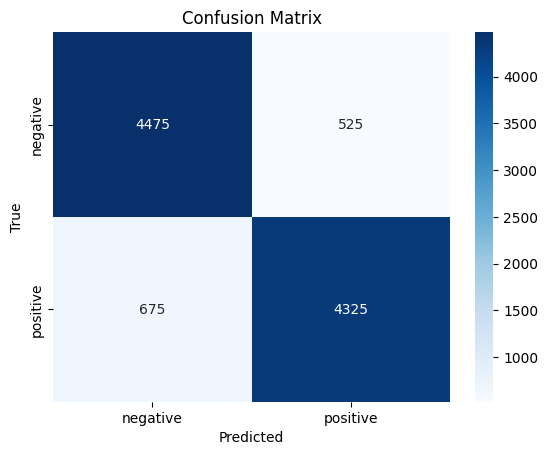

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, label_map, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    class_names = list(label_map.keys())
    fig, ax = plt.subplots()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path)        
        print(f"Image has been saved to {save_path}")
    plt.show()

label_map = {'negative':0, 'positive':1}
plot_confusion_matrix(y_true, predicted_labels, label_map, save_path=None)

In [15]:
import plotly.express as px

# Predicted Sentiment Distribution
positive_count = predicted_labels.count("positive")
negative_count = predicted_labels.count("negative")

sentiment_counts = {
    "Positive": positive_count,
    "Negative": negative_count
}

fig = px.pie(
    names=list(sentiment_counts.keys()),
    values=list(sentiment_counts.values()),
    hole=0.5,
    title="Predicted Sentiment Distribution",
    color_discrete_sequence=[ "#FF0000", "#008000"]
)

fig.update_traces(
    textinfo="percent",
    hovertemplate="%{label}<br>Count: %{value}<br>Percentage: %{percent}<extra></extra>"
)

fig.show()